## To Do ##
1. dataset split
2. PCA
3. LDA
4. PCA -> LDA

In [4]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

In [5]:
olivetti_faces = fetch_olivetti_faces()
data = olivetti_faces.data
target = olivetti_faces.target
images = olivetti_faces.images

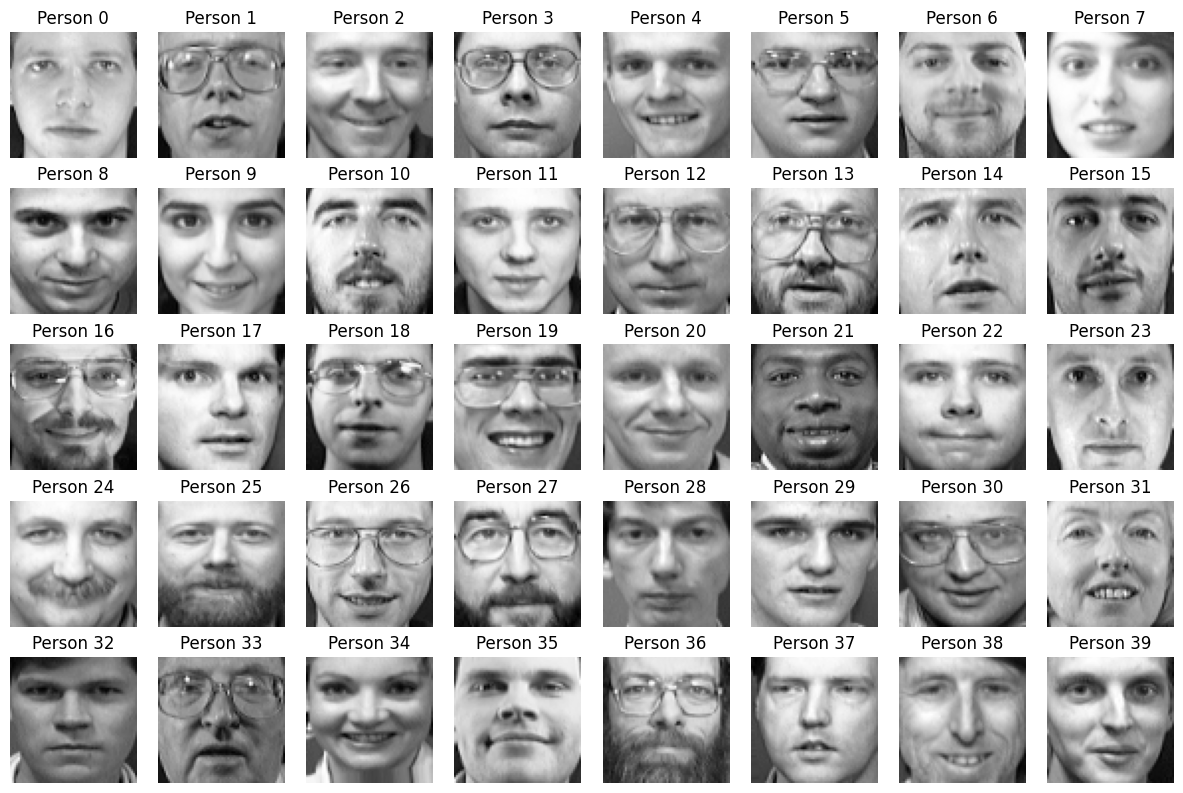

In [6]:
unique_imgs = []
for person in range(40):
    idx = (target == person).argmax()   # first index for that person
    unique_imgs.append(images[idx])

# Plot 5x8 grid
fig, axes = plt.subplots(5, 8, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    ax.imshow(unique_imgs[i], cmap='gray')
    ax.set_title(f"Person {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
## Split the dataset into training and testing sets ##
from sklearn.model_selection import train_test_split

X = data
y = target

# Ratio each class equal with 8:2. Stratification ensure class balance in splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 

Xtr, ytr = X_train, y_train

## Gaussian Classifier on Raw Data ##

In [6]:
qda_raw = QuadraticDiscriminantAnalysis(store_covariance=True, reg_param=0.01)
qda_raw.fit(Xtr, y_train)
ypred_train = qda_raw.predict(Xtr)
ypred_test = qda_raw.predict(X_test)

acc_train = accuracy_score(ytr, ypred_train)
acc_test = accuracy_score(y_test, ypred_test)

print(f"Training Accuracy (Raw): {acc_train:.4f}")
print(f"Testing Accuracy (Raw): {acc_test:.4f}")

/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full ran

Training Accuracy (Raw): 0.0031
Testing Accuracy (Raw): 0.1000


## Find Data Variance ##

In [ ]:
q = Xtr.shape[0] # number of training samples 1x1
mu = np.mean(Xtr, axis=0) # mean of training data (4096,)

Xtr_centered = Xtr - mu # (320,4096)

X_test_centered = X_test - mu


# SVD for optimizing eigen decomposition
U, S, Vt = np.linalg.svd(Xtr_centered, full_matrices=False)

# Eigenvalues and Eigenvectors of St can be obtained from SVD results
eigenvalues = (S ** 2) / (q - 1) # (320,)
eigenvectors = Vt.T # (4096,320)

## Means Square From Raw Data ##

In [ ]:
# Compute class means
classes = np.unique(ytr)
class_means = np.array([Xtr[ytr == c].mean(axis=0) for c in classes])

# Predict by nearest mean (min squared distance)
diff = X_test[:, None, :] - class_means[None, :, :]
dists = np.sum(diff**2, axis=2)
ypred = np.argmin(dists, axis=1)

# Metrics
print("Accuracy:", accuracy_score(y_test, ypred))
print("Confusion Matrix:\n", confusion_matrix(y_test, ypred))


Accuracy: 0.8375
Confusion Matrix:
 [[0 0 0 ... 0 0 1]
 [0 2 0 ... 0 0 0]
 [0 0 2 ... 0 0 0]
 ...
 [0 0 0 ... 1 0 1]
 [0 0 0 ... 0 2 0]
 [0 0 0 ... 0 0 1]]


## PCA ##

In [ ]:
eigenvectors.shape

(4096, 320)

In [ ]:
#image reconstruction example
num_components = 10

eigenvectors_subset = eigenvectors[:, :num_components]  # (4096,num_components)
Xtr_reduced = np.dot(Xtr_centered, eigenvectors_subset)  # (320,num_components)
Xtr_reconstructed = np.dot(Xtr_reduced, eigenvectors_subset.T) + mu

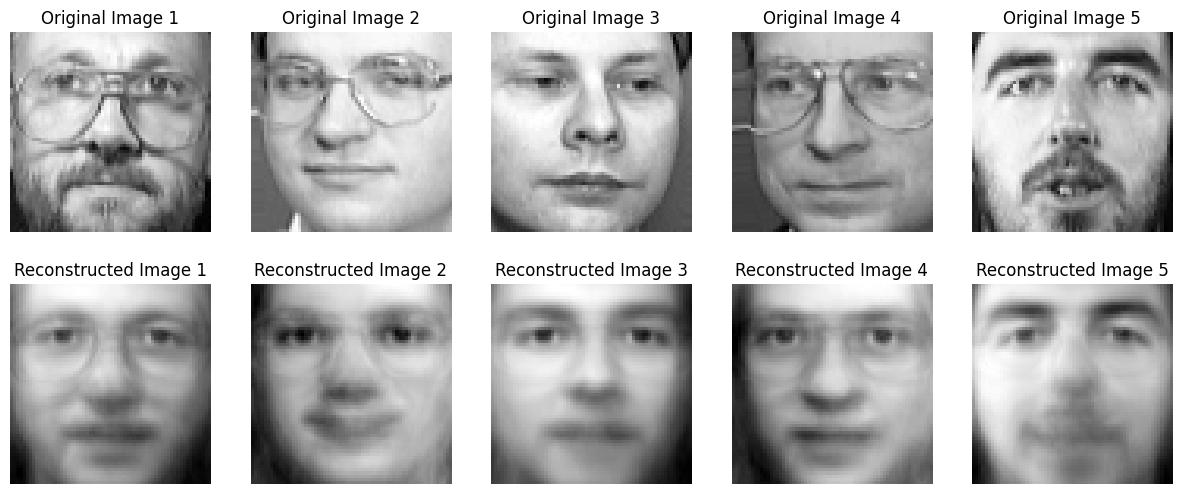

In [ ]:
# image visualization
fig, axes = plt.subplots(2, 5, figsize=(15, 6)) 
for i in range(5):
    axes[0, i].imshow(Xtr[i].reshape(64, 64), cmap='gray')
    axes[0, i].set_title(f'Original Image {i+1}')
    axes[0, i].axis('off')

    axes[1, i].imshow(Xtr_reconstructed[i].reshape(64, 64), cmap='gray')
    axes[1, i].set_title(f'Reconstructed Image {i+1}')
    axes[1, i].axis('off')

### Means Square after PCA ###

In [ ]:
classes = np.unique(ytr)
class_means = np.array([Xtr_reduced[ytr == c].mean(axis=0) for c in classes])

# Predict by nearest mean (min squared distance)
diff = Xtr_reduced[:, None, :] - class_means[None, :, :]
dists = np.sum(diff**2, axis=2)
ypred = np.argmin(dists, axis=1)

# Metrics
print("Accuracy:", accuracy_score(y_train, ypred))
print("Confusion Matrix:\n", confusion_matrix(y_train, ypred))

Accuracy: 0.9375
Confusion Matrix:
 [[7 0 0 ... 0 0 1]
 [0 8 0 ... 0 0 0]
 [0 0 8 ... 0 0 0]
 ...
 [0 0 0 ... 7 0 1]
 [0 0 0 ... 0 8 0]
 [0 0 0 ... 0 0 5]]


/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full ran

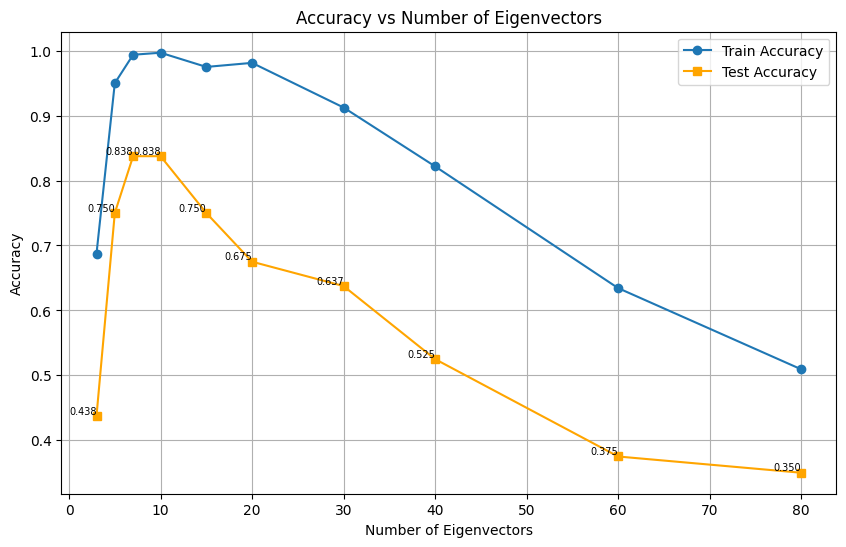

In [ ]:
#image reconstruction example
eigen_nums = [10, 15, 20, 30, 40, 60, 80,  120, 150, 280]
# reg_params = [0.01, 0.05,0.1, 0.5]
reg_params = [0.1]  
acc_train = [[0 for _ in eigen_nums] for _ in reg_params]
acc_test = []
i = 0
for reg in reg_params:
    j = 0
    for num in eigen_nums:
        eigenvectors_subset = eigenvectors[:, :num]  # (4096,num_components)
        Xtr_reduced = np.dot(Xtr_centered, eigenvectors_subset)  # (320,num_components)
        X_test_reduced = np.dot(X_test_centered, eigenvectors_subset)  # (80,num_components)
        Xtr_reconstructed = np.dot(Xtr_reduced, eigenvectors_subset.T) + mu

        classes = np.unique(ytr)
        class_means = np.array([Xtr_reduced[ytr == c].mean(axis=0) for c in classes])

        # Predict by nearest mean (min squared distance)
        diff_train = Xtr_reduced[:, None, :] - class_means[None, :, :]
        diff_test = X_test_reduced[:, None, :] - class_means[None, :, :]
        dists_train = np.sum(diff_train**2, axis=2)
        dists_test = np.sum(diff_test**2, axis=2)
        # ypred_train = np.argmin(dists_train, axis=1)
        # ypred_test = np.argmin(dists_test, axis=1)

        qda_raw = QuadraticDiscriminantAnalysis(store_covariance=True, reg_param=reg)
        qda_raw.fit(Xtr_reduced, y_train)
        ypred_train = qda_raw.predict(Xtr_reduced)
        ypred_test = qda_raw.predict(X_test_reduced)
        acc_train[i][j] = (accuracy_score(y_train, ypred_train))
        acc_test.append(accuracy_score(y_test, ypred_test))
        j += 1
    i += 1

# Plot accuracy vs number of eigenvectors
plt.figure(figsize=(10, 6))
plt.plot(eigen_nums, acc_train[0], marker='o', label='Train Accuracy')
# plt.plot(eigen_nums, acc_train[1], marker='o', label='reg=0.05')
# plt.plot(eigen_nums, acc_train[2], marker='o', label='reg=0.1')
# plt.plot(eigen_nums, acc_train[3], marker='o', label='reg=0.5')
plt.plot(eigen_nums, acc_test, marker='s', color='orange', label='Test Accuracy')
for x, y in zip(eigen_nums, acc_test):
    plt.text(x, y, f"{y:.3f}", ha='right', va='bottom', fontsize=7)
plt.title('Accuracy vs Number of Eigenvectors')
plt.xlabel('Number of Eigenvectors')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()
plt.show()


## LDA ##

In [13]:
# Implementing LDA
classes = np.unique(ytr)
c = classes.shape[0]
n_train, d = Xtr.shape

mean = np.zeros((c, d))
cov = np.zeros((c, d, d))

Sw = np.zeros((d, d))
Sb = np.zeros((d, d))

for c in classes:
    Xc = X_train[y_train == c]       # samples of class c
    mu_c = Xc.mean(axis=0)           # mean of class c

    # within-class scatter
    Sw += (Xc - mu_c).T @ (Xc - mu_c)

    # between-class scatter
    diff = (mu_c - mu).reshape(-1, 1)
    Sb += Xc.shape[0] * (diff @ diff.T)

In [14]:
Sw_inv = np.linalg.pinv(Sw)
eigenvalues_lda, eigenvectors_lda = np.linalg.eig(Sw_inv @ Sb) # (4096,) , (4096,4096)

## LDA 1: Regularization ##

In [40]:
Sw_reg = Sw + 0.00001 * np.eye(d)

In [41]:
from scipy.linalg import eigh

eigenvalues_lda, eigenvectors_lda = eigh(Sb, Sw_reg) # (4096,) , (4096,4096)

In [ ]:
Xtr_lda = Xtr_centered @ eigenvectors_lda  # (320,4096)
X_test_lda = X_test_centered @ eigenvectors_lda  # (80,4096)

In [ ]:
qda_lda = QuadraticDiscriminantAnalysis(store_covariance=True, reg_param=0.01)
qda_lda.fit(Xtr_lda, y_train)
y_lda_train_pred = qda_lda.predict(Xtr_lda)
y_lda_test_pred = qda_lda.predict(X_test_lda)

print(f'accuracy score of train data: {accuracy_score(y_lda_train_pred, y_train)}')
print(f'accuracy score of test data: {accuracy_score(y_lda_test_pred, y_test)}')

/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full ran

accuracy score of train data: 1.0
accuracy score of test data: 0.2


/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full ran

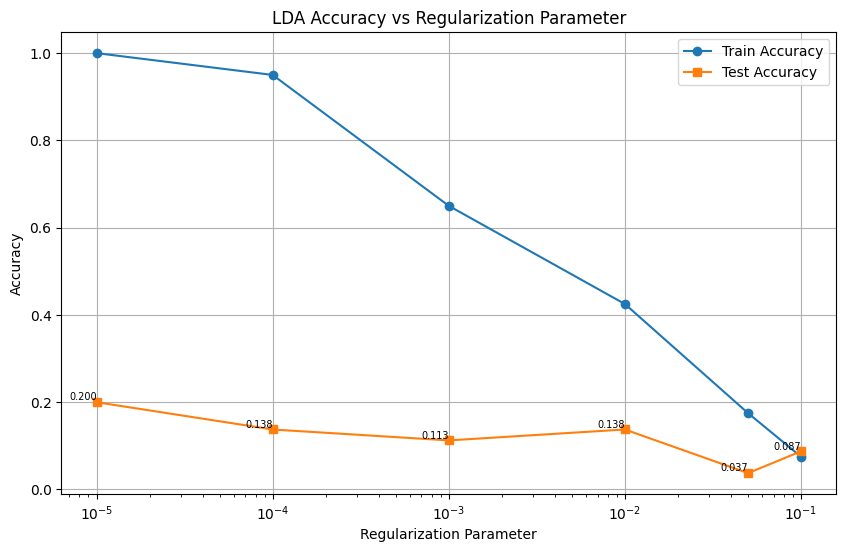

In [43]:
regularizer = [0.00001, 0.0001, 0.001, 0.01, 0.05, 0.1]
acc_lda_train = []
acc_lda_test = []
for reg in regularizer:
    Sw_reg = Sw + reg * np.eye(d)
    eigenvalues_lda, eigenvectors_lda = eigh(Sb, Sw_reg) # (4096,) , (4096,4096)
    Xtr_lda = Xtr_centered @ eigenvectors_lda  # (320,4096)
    X_test_lda = X_test_centered @ eigenvectors_lda  # (80
    qda_lda = QuadraticDiscriminantAnalysis(store_covariance=True, reg_param=0.01)
    qda_lda.fit(Xtr_lda, y_train)
    y_lda_train_pred = qda_lda.predict(Xtr_lda)
    y_lda_test_pred = qda_lda.predict(X_test_lda)
    acc_lda_train.append(accuracy_score(y_lda_train_pred, y_train))
    acc_lda_test.append(accuracy_score(y_lda_test_pred, y_test))

# Plot accuracy vs regularization parameter
plt.figure(figsize=(10, 6))
plt.plot(regularizer, acc_lda_train, marker='o', label='Train Accuracy')
plt.plot(regularizer, acc_lda_test, marker='s', label='Test Accuracy')
for x, y in zip(regularizer, acc_lda_test):
    plt.text(x, y, f"{y:.3f}", ha='right', va='bottom', fontsize=7)
plt.xscale('log')
plt.title('LDA Accuracy vs Regularization Parameter')
plt.xlabel('Regularization Parameter')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()
plt.show()

## PCA -> LDA ##


In [80]:
k_pca = 7 # from q - c

In [81]:
# Center training and test data with training mean
mu_pca = X_train.mean(axis=0)
Xtr_c  = X_train - mu_pca
Xte_c  = X_test  - mu_pca

# SVD-based PCA
U, S, Vt = np.linalg.svd(Xtr_c, full_matrices=False)   # Vt shape: (d, d_or_n)
W_pca = Vt[:k_pca].T                                      # (d, k) – first k eigenvectors



In [82]:
# Project to PCA space
Xtr_pca = Xtr_c @ W_pca        # (n_train, k)
Xte_pca = Xte_c @ W_pca        # (n_test,  k)


In [ ]:

classes = np.unique(y_train)
n_classes = classes.size
_, d_pca = Xtr_pca.shape


# global mean in PCA space
mu_lda = Xtr_pca.mean(axis=0)

Sw_pca = np.zeros((d_pca, d_pca))
Sb_pca = np.zeros((d_pca, d_pca))

for cls in classes:
    Xc = Xtr_pca[y_train == cls]
    mu_c = Xc.mean(axis=0)

    # within-class scatter
    Sw_pca += (Xc - mu_c).T @ (Xc - mu_c)

    # between-class scatter
    diff = (mu_c - mu_lda).reshape(-1, 1)
    Sb_pca  += Xc.shape[0] * (diff @ diff.T)

# regularize Sw (still good practice even after PCA)
reg = 1e-3
Sw_reg = Sw + reg * np.eye(d_pca)

# Solve Sb v = λ Sw_reg v  (generalized symmetric eigenproblem)
eigvals, eigvecs = eigh(Sb_pca, Sw_pca)

# sort by descending eigenvalue
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# keep at most c-1 LDA dimensions
m = min(n_classes - 1, d_pca)
W_lda = eigvecs[:, :m]                    # (d_pca, m)


In [84]:
Xtr_lda = (Xtr_pca - mu_lda) @ W_lda      # (n_train, m)
Xte_lda = (Xte_pca - mu_lda) @ W_lda      # (n_test,  m)


In [85]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda_lda = QuadraticDiscriminantAnalysis(store_covariance=True, reg_param=0.01)
qda_lda.fit(Xtr_lda, y_train)

y_lda_train_pred = qda_lda.predict(Xtr_lda)
y_lda_test_pred  = qda_lda.predict(Xte_lda)

print("PCA→LDA + QDA train acc:", accuracy_score(y_train, y_lda_train_pred))
print("PCA→LDA + QDA test  acc:",  accuracy_score(y_test,  y_lda_test_pred))


PCA→LDA + QDA train acc: 0.8875
PCA→LDA + QDA test  acc: 0.75


/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 2 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/home/fazil/Documents/Univ/IE4476/ie4476/lib/python3.12/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 3 is not full ran

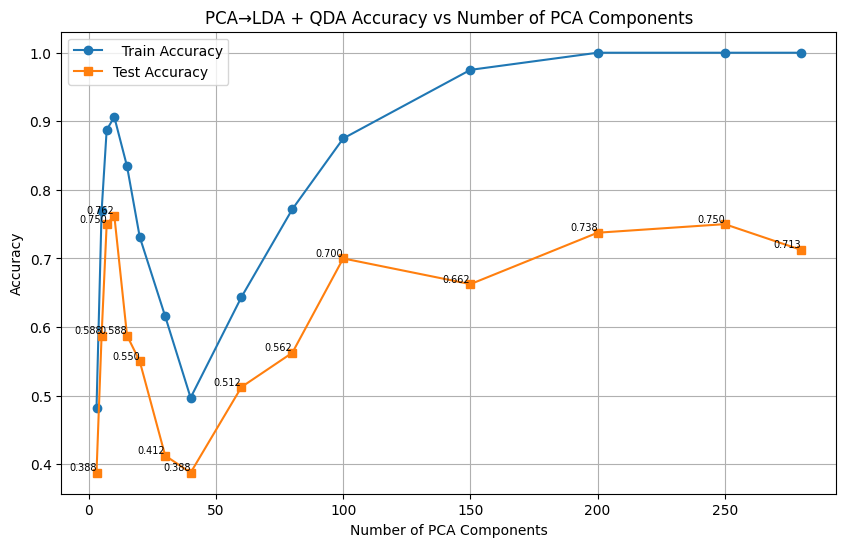

In [12]:
k_pca = [3, 5, 7, 10, 15, 20, 30, 40, 60, 80, 100, 150, 200, 250, 280]
acc_pca_lda_train= []
acc_pca_lda_test = []
for k in k_pca:
        # Center training and test data with training mean
    mu_pca = X_train.mean(axis=0)
    Xtr_c  = X_train - mu_pca
    Xte_c  = X_test  - mu_pca

    # SVD-based PCA
    U, S, Vt = np.linalg.svd(Xtr_c, full_matrices=False)   # Vt shape: (d, d_or_n)
    W_pca = Vt[:k].T                                      # (d, k) – first k eigenvectors

    # Project to PCA space
    Xtr_pca = Xtr_c @ W_pca        # (n_train, k)
    Xte_pca = Xte_c @ W_pca        # (n_test,  k)

    classes = np.unique(y_train)
    n_classes = classes.size
    _, d_pca = Xtr_pca.shape


    # global mean in PCA space
    mu_lda = Xtr_pca.mean(axis=0)

    Sw_pca = np.zeros((d_pca, d_pca))
    Sb_pca = np.zeros((d_pca, d_pca))

    for cls in classes:
        Xc = Xtr_pca[y_train == cls]
        mu_c = Xc.mean(axis=0)

        # within-class scatter
        Sw_pca += (Xc - mu_c).T @ (Xc - mu_c)

        # between-class scatter
        diff = (mu_c - mu_lda).reshape(-1, 1)
        Sb_pca  += Xc.shape[0] * (diff @ diff.T)

    # regularize Sw (still good practice even after PCA)
    reg = 5e-2
    Sw_pca_reg = Sw_pca + reg * np.eye(d_pca)

    # Solve Sb v = λ Sw_reg v  (generalized symmetric eigenproblem)
    eigvals, eigvecs = eigh(Sb_pca, Sw_pca_reg)

    # sort by descending eigenvalue
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # keep at most c-1 LDA dimensions
    m = min(n_classes - 1, d_pca)
    W_lda = eigvecs[:, :m]  

    Xtr_lda = (Xtr_pca - mu_lda) @ W_lda      # (n_train, m)
    Xte_lda = (Xte_pca - mu_lda) @ W_lda      # (n_test,  m)


    qda_lda = QuadraticDiscriminantAnalysis(store_covariance=True, reg_param=0.01)
    qda_lda.fit(Xtr_lda, y_train)

    y_lda_train_pred = qda_lda.predict(Xtr_lda)
    y_lda_test_pred  = qda_lda.predict(Xte_lda)

    acc_pca_lda_train.append(accuracy_score(y_train, y_lda_train_pred))
    acc_pca_lda_test.append(accuracy_score(y_test,  y_lda_test_pred))

# Plot accuracy vs number of PCA components
plt.figure(figsize=(10, 6))
plt.plot(k_pca, acc_pca_lda_train, marker='o', label='  Train Accuracy')
plt.plot(k_pca, acc_pca_lda_test, marker='s', label='Test Accuracy')
for x, y in zip(k_pca, acc_pca_lda_test):
    plt.text(x, y, f"{y:.3f}", ha='right', va='bottom', fontsize=7)
plt.title('PCA→LDA + QDA Accuracy vs Number of PCA Components')
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()
plt.show()  





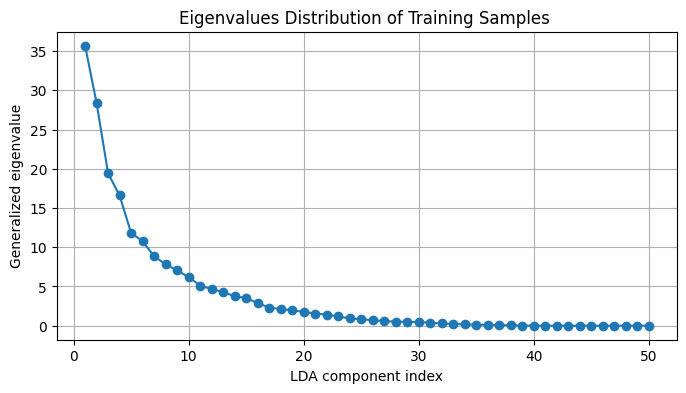

In [18]:
k = 50  # pick one
# ... build Xtr_pca, Sw_pca, Sb_pca as you already do for that k ...

mu_pca = X_train.mean(axis=0)
Xtr_c  = X_train - mu_pca
Xte_c  = X_test  - mu_pca

# SVD-based PCA
U, S, Vt = np.linalg.svd(Xtr_c, full_matrices=False)   # Vt shape: (d, d_or_n)
W_pca = Vt[:k].T                                      # (d, k) – first k eigenvectors

# Project to PCA space
Xtr_pca = Xtr_c @ W_pca        # (n_train, k)
Xte_pca = Xte_c @ W_pca        # (n_test,  k)

classes = np.unique(y_train)
n_classes = classes.size
_, d_pca = Xtr_pca.shape

# global mean in PCA space
mu_lda = Xtr_pca.mean(axis=0)

Sw_pca = np.zeros((d_pca, d_pca))
Sb_pca = np.zeros((d_pca, d_pca))

for cls in classes:
    Xc = Xtr_pca[y_train == cls]
    mu_c = Xc.mean(axis=0)

    # within-class scatter
    Sw_pca += (Xc - mu_c).T @ (Xc - mu_c)

    # between-class scatter
    diff = (mu_c - mu_lda).reshape(-1, 1)
    Sb_pca  += Xc.shape[0] * (diff @ diff.T)

reg = 1e-2
Sw_pca_reg = Sw_pca + reg * np.eye(d_pca)
eigvals, eigvecs = eigh(Sb_pca, Sw_pca_reg)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]


m = min(n_classes - 1, d_pca)
lda_eigvals = eigvals[:m]

plt.figure(figsize=(8,4))
plt.plot(range(1, eigvals.shape[0] +1), eigvals, marker='o')
plt.xlabel("LDA component index")
plt.ylabel("Generalized eigenvalue")
plt.title(f"Eigenvalues Distribution of Training Samples ")
plt.grid(True)
plt.show()


In [1]:
import numpy as np

class GaussianProbSubspaceClassifier:
    def __init__(self, m, reg=1e-6):
        """
        m   : number of 'reliable' eigen-dimensions (top m eigenvalues)
        reg : small constant added to covariance diagonal for stability.
        """
        self.m = m
        self.reg = reg
        self.classes_ = None
        self.params_ = {}  # class -> dict of mean, eigvecs, eigvals, rho_av, b
    
    def fit(self, X_train, y_train):
        """
        X_train: (N_samples, N_features)
        y_train: (N_samples,)
        """
        X_train = np.asarray(X_train)
        y_train = np.asarray(y_train)
        N, d = X_train.shape
        
        if self.m > d:
            raise ValueError(f"m={self.m} cannot be > feature dimension d={d}")
        
        self.classes_, counts = np.unique(y_train, return_counts=True)
        
        for cls, Ni in zip(self.classes_, counts):
            Xc = X_train[y_train == cls]          # (Ni, d)
            mu = Xc.mean(axis=0)                  # (d,)
            Xc_centered = Xc - mu                 # (Ni, d)
            
            # covariance estimate
            Sigma = (Xc_centered.T @ Xc_centered) / Ni  # (d, d)
            Sigma_reg = Sigma + self.reg * np.eye(d)
            
            # eigendecomposition (symmetric -> eigh)
            eigvals, eigvecs = np.linalg.eigh(Sigma_reg)   # ascending order
            # sort descending for clarity (optional)
            idx = np.argsort(eigvals)[::-1]
            eigvals = eigvals[idx]
            eigvecs = eigvecs[:, idx]
            
            # m must be <= number of nonzero/meaningful eigvals, but we keep it simple
            m = self.m
            if m < d:
                # rho_av = average of small eigenvalues λ_{m+1}..λ_n
                rho_av = eigvals[m:].mean()
            else:
                rho_av = None  # no tail
            
            # prior
            prior = Ni / N
            log_det = np.sum(np.log(eigvals))     # det Σ = Π λ_k
            b_i = -0.5 * log_det + np.log(prior)
            
            self.params_[cls] = {
                "mean": mu,
                "eigvecs": eigvecs,
                "eigvals": eigvals,
                "rho_av": rho_av,
                "b": b_i
            }
        return self
    
    def _g_i(self, x, params):
        mu = params["mean"]
        Phi = params["eigvecs"]
        lam = params["eigvals"]
        rho_av = params["rho_av"]
        b_i = params["b"]
        m = self.m
        
        diff = x - mu                  # (d,)
        z_diff = Phi.T @ diff          # (d,) = φ_k^T(x-μ_i)
        
        if rho_av is None or m >= len(lam):
            # fall back to full Mahalanobis if no tail
            D_head = np.sum((z_diff ** 2) / lam)
            g = -0.5 * D_head + b_i
        else:
            # head: k = 1..m, use λ_k
            D_head = np.sum((z_diff[:m] ** 2) / lam[:m])
            # tail: k = m+1..n, use ρ_av
            D_tail = np.sum((z_diff[m:] ** 2) / rho_av)
            g = -0.5 * (D_head + D_tail) + b_i
        
        return g
    
    def predict(self, X):
        X = np.asarray(X)
        N_test = X.shape[0]
        y_pred = np.empty(N_test, dtype=self.classes_.dtype)
        
        for i, x in enumerate(X):
            best_cls = None
            best_g = -np.inf
            for cls in self.classes_:
                g = self._g_i(x, self.params_[cls])
                if g > best_g:
                    best_g = g
                    best_cls = cls
            y_pred[i] = best_cls
        return y_pred


m=10, accuracy=0.9750
m=20, accuracy=0.9750
Skipping m=40 because m > feature_dim=39
Skipping m=80 because m > feature_dim=39
Skipping m=160 because m > feature_dim=39


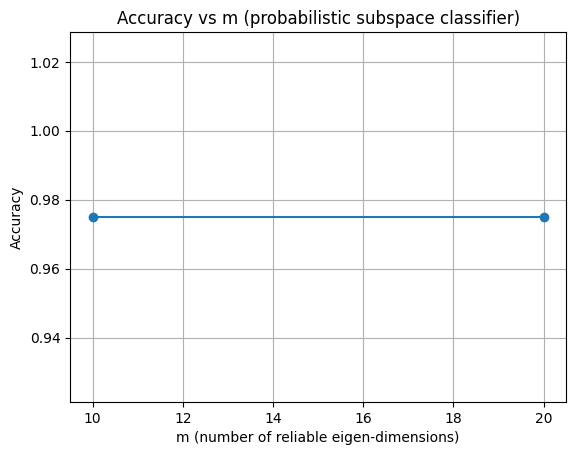

In [19]:
import numpy as np
import matplotlib.pyplot as plt

m_list = [10, 20, 40, 80, 160]
accuracies = []


# keep at most c-1 LDA dimensions
m = min(n_classes - 1, d_pca)
W_lda = eigvecs[:, :m]  

Xtr_lda = (Xtr_pca - mu_lda) @ W_lda      # (n_train, m)
Xte_lda = (Xte_pca - mu_lda) @ W_lda      # (n_test,  m)

d = Xtr_lda.shape[1]  # feature dimension after PCA+LDA

for m in m_list:
    # clip m to feature dimension (or skip if too large)
    if m > d:
        print(f"Skipping m={m} because m > feature_dim={d}")
        accuracies.append(np.nan)
        continue
    
    clf = GaussianProbSubspaceClassifier(m=m, reg=1e-4)
    clf.fit(Xtr_lda, y_train)
    
    y_pred = clf.predict(Xte_lda)
    acc = accuracy_score(y_pred, y_test)
    accuracies.append(acc)
    print(f"m={m}, accuracy={acc:.4f}")

# Plot accuracy vs m
plt.figure()
plt.plot(m_list, accuracies, marker='o')
plt.xlabel('m (number of reliable eigen-dimensions)')
plt.ylabel('Accuracy')
plt.title('Accuracy vs m (probabilistic subspace classifier)')
plt.grid(True)
plt.show()


m=10, accuracy=0.8500
m=10, accuracy=0.9375
m=10, accuracy=0.9500
m=10, accuracy=0.9750
m=10, accuracy=0.9875
m=10, accuracy=0.9875
m=10, accuracy=0.9750
m=10, accuracy=0.9750
m=10, accuracy=0.9750
m=10, accuracy=0.9625
m=10, accuracy=0.9250
m=10, accuracy=0.9625


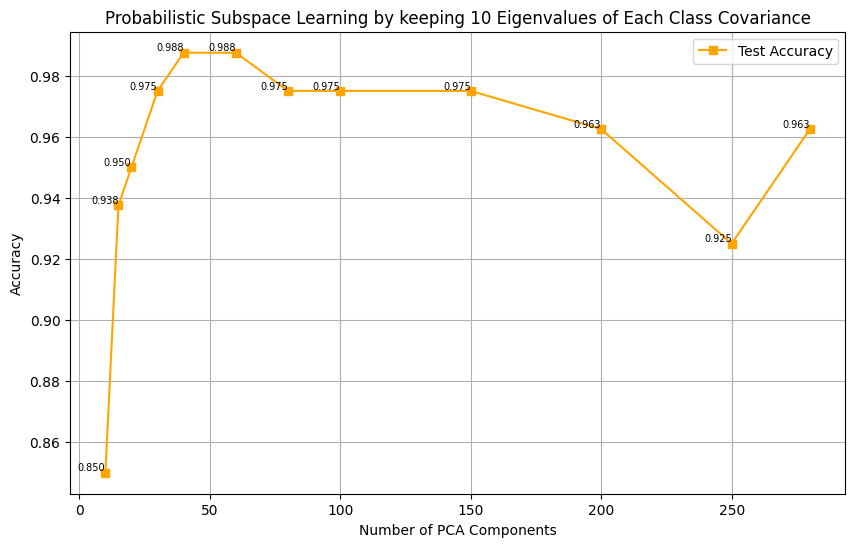

In [25]:
k_pca = [10, 15, 20, 30, 40, 60, 80, 100, 150, 200, 250, 280]
m_list = [10]
acc_pca_lda_train= []
acc_pca_lda_test = []
for k in k_pca:
        # Center training and test data with training mean
    mu_pca = X_train.mean(axis=0)
    Xtr_c  = X_train - mu_pca
    Xte_c  = X_test  - mu_pca

    # SVD-based PCA
    U, S, Vt = np.linalg.svd(Xtr_c, full_matrices=False)   # Vt shape: (d, d_or_n)
    W_pca = Vt[:k].T                                      # (d, k) – first k eigenvectors

    # Project to PCA space
    Xtr_pca = Xtr_c @ W_pca        # (n_train, k)
    Xte_pca = Xte_c @ W_pca        # (n_test,  k)

    classes = np.unique(y_train)
    n_classes = classes.size
    _, d_pca = Xtr_pca.shape


    # global mean in PCA space
    mu_lda = Xtr_pca.mean(axis=0)

    Sw_pca = np.zeros((d_pca, d_pca))
    Sb_pca = np.zeros((d_pca, d_pca))

    for cls in classes:
        Xc = Xtr_pca[y_train == cls]
        mu_c = Xc.mean(axis=0)

        # within-class scatter
        Sw_pca += (Xc - mu_c).T @ (Xc - mu_c)

        # between-class scatter
        diff = (mu_c - mu_lda).reshape(-1, 1)
        Sb_pca  += Xc.shape[0] * (diff @ diff.T)

    # regularize Sw (still good practice even after PCA)
    reg = 5e-2
    Sw_pca_reg = Sw_pca + reg * np.eye(d_pca)

    # Solve Sb v = λ Sw_reg v  (generalized symmetric eigenproblem)
    eigvals, eigvecs = eigh(Sb_pca, Sw_pca_reg)

    # sort by descending eigenvalue
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # keep at most c-1 LDA dimensions
    m = min(n_classes - 1, d_pca)
    W_lda = eigvecs[:, :m]  

    Xtr_lda = (Xtr_pca - mu_lda) @ W_lda      # (n_train, m)
    Xte_lda = (Xte_pca - mu_lda) @ W_lda      # (n_test,  m)

    d = Xtr_lda.shape[1]  # feature dimension after PCA+LDA

    for m in m_list:
        # clip m to feature dimension (or skip if too large)
        if m > d:
            print(f"Skipping m={m} because m > feature_dim={d}")
            accuracies.append(np.nan)
            continue
        
        clf = GaussianProbSubspaceClassifier(m=m, reg=1e-4)
        clf.fit(Xtr_lda, y_train)
        
        y_pred = clf.predict(Xte_lda)
        acc = accuracy_score(y_pred, y_test)
        acc_pca_lda_test.append(acc)
        print(f"m={m}, accuracy={acc:.4f}")


# Plot accuracy vs number of PCA components
plt.figure(figsize=(10, 6))
plt.plot(k_pca, acc_pca_lda_test, marker='s', color='orange', label='Test Accuracy')
for x, y in zip(k_pca, acc_pca_lda_test):
    plt.text(x, y, f"{y:.3f}", ha='right', va='bottom', fontsize=7)
plt.title('Probabilistic Subspace Learning by keeping 10 Eigenvalues of Each Class Covariance')
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()
plt.show()  





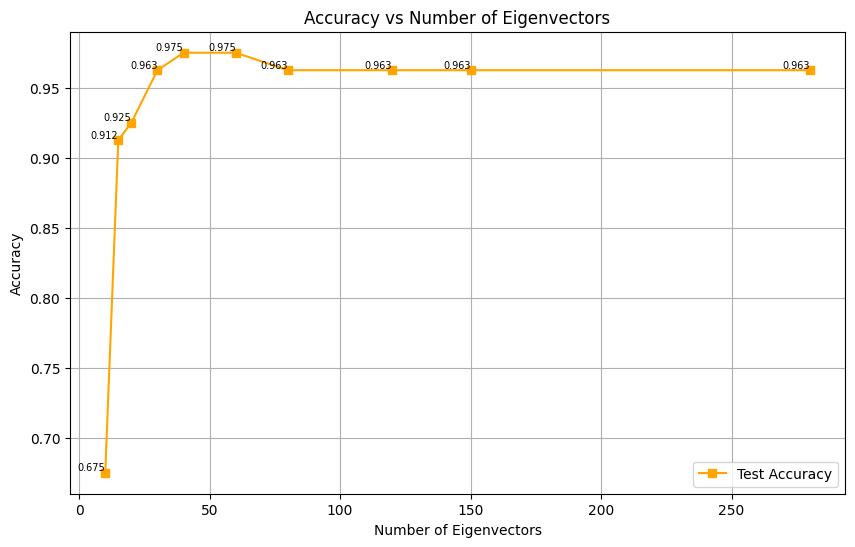

In [30]:
# PCA after subspace learning
#image reconstruction example
num_components = 10

q = Xtr.shape[0] # number of training samples 1x1
mu = np.mean(Xtr, axis=0) # mean of training data (4096,)

Xtr_centered = Xtr - mu # (320,4096)
X_test_centered = X_test - mu

# SVD for optimizing eigen decomposition
U, S, Vt = np.linalg.svd(Xtr_centered, full_matrices=False)

# Eigenvalues and Eigenvectors of St can be obtained from SVD results
eigenvalues = (S ** 2) / (q - 1) # (320,)
eigenvectors = Vt.T # (4096,320)

eigenvectors_subset = eigenvectors[:, :num_components]  # (4096,num_components)
Xtr_reduced = np.dot(Xtr_centered, eigenvectors_subset)  # (320,num_components)
Xtr_reconstructed = np.dot(Xtr_reduced, eigenvectors_subset.T) + mu

eigen_nums = [10, 15, 20, 30, 40, 60, 80,  120, 150, 280]
# reg_params = [0.01, 0.05,0.1, 0.5]
reg_params = [0.1]  
acc_train = [[0 for _ in eigen_nums] for _ in reg_params]
acc_test = []
i = 0
for reg in reg_params:
    j = 0
    for num in eigen_nums:
        eigenvectors_subset = eigenvectors[:, :num]  # (4096,num_components)
        Xtr_reduced = np.dot(Xtr_centered, eigenvectors_subset)  # (320,num_components)
        X_test_reduced = np.dot(X_test_centered, eigenvectors_subset)  # (80,num_components)
        Xtr_reconstructed = np.dot(Xtr_reduced, eigenvectors_subset.T) + mu

        classes = np.unique(ytr)
        class_means = np.array([Xtr_reduced[ytr == c].mean(axis=0) for c in classes])

        # Predict by nearest mean (min squared distance)

        clf = GaussianProbSubspaceClassifier(m=m, reg=1e-4)
        clf.fit(Xtr_reduced, y_train)

        ypred_test = clf.predict(X_test_reduced)
        acc_test.append(accuracy_score(y_test, ypred_test))
        j += 1
    i += 1

# Plot accuracy vs number of eigenvectors
plt.figure(figsize=(10, 6))
plt.plot(eigen_nums, acc_test, marker='s', color='orange', label='Test Accuracy')
for x, y in zip(eigen_nums, acc_test):
    plt.text(x, y, f"{y:.3f}", ha='right', va='bottom', fontsize=7)
plt.title('Accuracy vs Number of Eigenvectors')
plt.xlabel('Number of Eigenvectors')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()
plt.show()


In [31]:
# Enhanced Probabilistic Subspace Learning
import numpy as np

class GaussianEnhancedProbSubspaceClassifier:
    """
    Solution 3: enhanced probabilistic subspace learning
    Head (1..m): use true eigenvalues λ_k
    Tail (m+1..n): use constant ρ_up = λ_{m+1} = max tail eigenvalue
    """
    def __init__(self, m, reg=1e-6):
        """
        m   : number of 'reliable' eigen-dimensions (top m eigenvalues)
        reg : small constant added to covariance diagonal for stability.
        """
        self.m = m
        self.reg = reg
        self.classes_ = None
        self.params_ = {}  # class -> dict of mean, eigvecs, eigvals, rho_up, b
    
    def fit(self, X_train, y_train):
        """
        X_train: (N_samples, N_features)
        y_train: (N_samples,)
        """
        X_train = np.asarray(X_train)
        y_train = np.asarray(y_train)
        N, d = X_train.shape
        
        if self.m > d:
            raise ValueError(f"m={self.m} cannot be > feature dimension d={d}")
        
        self.classes_, counts = np.unique(y_train, return_counts=True)
        
        for cls, Ni in zip(self.classes_, counts):
            Xc = X_train[y_train == cls]          # (Ni, d)
            mu = Xc.mean(axis=0)                  # (d,)
            Xc_centered = Xc - mu                 # (Ni, d)
            
            # covariance estimate
            Sigma = (Xc_centered.T @ Xc_centered) / Ni  # (d, d)
            Sigma_reg = Sigma + self.reg * np.eye(d)
            
            # eigendecomposition (symmetric -> eigh)
            eigvals, eigvecs = np.linalg.eigh(Sigma_reg)   # ascending order
            # sort descending: λ_1 >= λ_2 >= ...
            idx = np.argsort(eigvals)[::-1]
            eigvals = eigvals[idx]
            eigvecs = eigvecs[:, idx]
            
            m = self.m
            if m < d:
                # Solution 3: ρ_up = λ_{m+1} = max(λ_k, k = m+1..n)
                rho_up = eigvals[m]   # because eigvals is 0-based and sorted desc
            else:
                rho_up = None  # no tail
            
            # prior P(ω_i)
            prior = Ni / N
            # use original eigvals for log|Σ|
            log_det = np.sum(np.log(eigvals))     # det Σ = Π λ_k
            b_i = -0.5 * log_det + np.log(prior)
            
            self.params_[cls] = {
                "mean": mu,
                "eigvecs": eigvecs,
                "eigvals": eigvals,
                "rho_up": rho_up,
                "b": b_i
            }
        return self
    
    def _g_i(self, x, params):
        mu = params["mean"]
        Phi = params["eigvecs"]
        lam = params["eigvals"]
        rho_up = params["rho_up"]
        b_i = params["b"]
        m = self.m
        
        diff = x - mu                  # (d,)
        z_diff = Phi.T @ diff          # (d,) = φ_k^T(x-μ_i)
        
        if rho_up is None or m >= len(lam):
            # fall back to full Mahalanobis if no tail
            D_head = np.sum((z_diff ** 2) / lam)
            g = -0.5 * D_head + b_i
        else:
            # head: k = 1..m, use λ_k
            D_head = np.sum((z_diff[:m] ** 2) / lam[:m])
            # tail: k = m+1..n, use ρ_up (a single constant)
            D_tail = np.sum((z_diff[m:] ** 2) / rho_up)
            g = -0.5 * (D_head + D_tail) + b_i
        
        return g
    
    def predict(self, X):
        X = np.asarray(X)
        N_test = X.shape[0]
        y_pred = np.empty(N_test, dtype=self.classes_.dtype)
        
        for i, x in enumerate(X):
            best_cls = None
            best_g = -np.inf
            for cls in self.classes_:
                g = self._g_i(x, self.params_[cls])
                if g > best_g:
                    best_g = g
                    best_cls = cls
            y_pred[i] = best_cls
        return y_pred


m=10, accuracy=0.8500
m=10, accuracy=0.9375
m=10, accuracy=0.9500
m=10, accuracy=0.9750
m=10, accuracy=0.9875
m=10, accuracy=0.9875
m=10, accuracy=0.9750
m=10, accuracy=0.9750
m=10, accuracy=0.9750
m=10, accuracy=0.9625
m=10, accuracy=0.9250
m=10, accuracy=0.9625


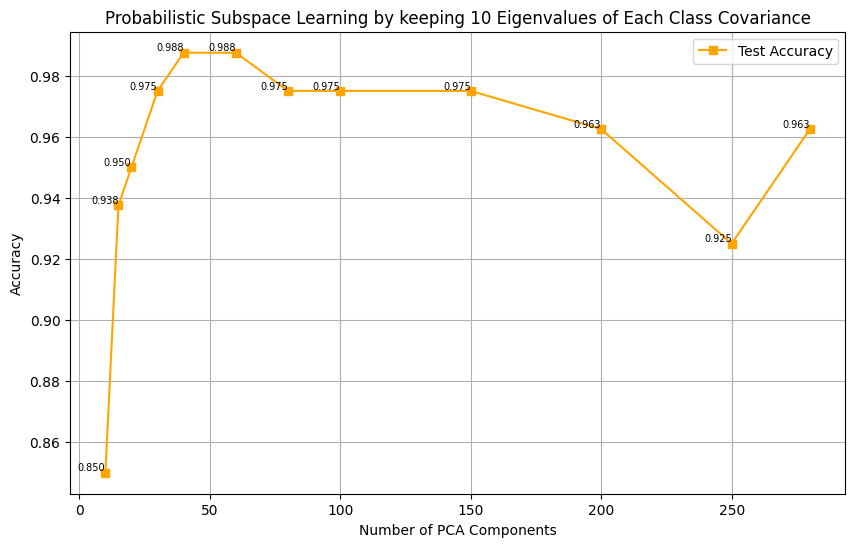

In [34]:
k_pca = [10, 15, 20, 30, 40, 60, 80, 100, 150, 200, 250, 280]
m_list = [10]
acc_pca_lda_train= []
acc_pca_lda_test = []
for k in k_pca:
        # Center training and test data with training mean
    mu_pca = X_train.mean(axis=0)
    Xtr_c  = X_train - mu_pca
    Xte_c  = X_test  - mu_pca

    # SVD-based PCA
    U, S, Vt = np.linalg.svd(Xtr_c, full_matrices=False)   # Vt shape: (d, d_or_n)
    W_pca = Vt[:k].T                                      # (d, k) – first k eigenvectors

    # Project to PCA space
    Xtr_pca = Xtr_c @ W_pca        # (n_train, k)
    Xte_pca = Xte_c @ W_pca        # (n_test,  k)

    classes = np.unique(y_train)
    n_classes = classes.size
    _, d_pca = Xtr_pca.shape


    # global mean in PCA space
    mu_lda = Xtr_pca.mean(axis=0)

    Sw_pca = np.zeros((d_pca, d_pca))
    Sb_pca = np.zeros((d_pca, d_pca))

    for cls in classes:
        Xc = Xtr_pca[y_train == cls]
        mu_c = Xc.mean(axis=0)

        # within-class scatter
        Sw_pca += (Xc - mu_c).T @ (Xc - mu_c)

        # between-class scatter
        diff = (mu_c - mu_lda).reshape(-1, 1)
        Sb_pca  += Xc.shape[0] * (diff @ diff.T)

    # regularize Sw (still good practice even after PCA)
    reg = 5e-2
    Sw_pca_reg = Sw_pca + reg * np.eye(d_pca)

    # Solve Sb v = λ Sw_reg v  (generalized symmetric eigenproblem)
    eigvals, eigvecs = eigh(Sb_pca, Sw_pca_reg)

    # sort by descending eigenvalue
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # keep at most c-1 LDA dimensions
    m = min(n_classes - 1, d_pca)
    W_lda = eigvecs[:, :m]  

    Xtr_lda = (Xtr_pca - mu_lda) @ W_lda      # (n_train, m)
    Xte_lda = (Xte_pca - mu_lda) @ W_lda      # (n_test,  m)

    d = Xtr_lda.shape[1]  # feature dimension after PCA+LDA

    for m in m_list:
        # clip m to feature dimension (or skip if too large)
        if m > d:
            print(f"Skipping m={m} because m > feature_dim={d}")
            accuracies.append(np.nan)
            continue
        
        clf = GaussianEnhancedProbSubspaceClassifier(m=m, reg=1e-4)
        clf.fit(Xtr_lda, y_train)
        
        y_pred = clf.predict(Xte_lda)
        acc = accuracy_score(y_pred, y_test)
        acc_pca_lda_test.append(acc)
        print(f"m={m}, accuracy={acc:.4f}")


# Plot accuracy vs number of PCA components
plt.figure(figsize=(10, 6))
plt.plot(k_pca, acc_pca_lda_test, marker='s', color='orange', label='Test Accuracy')
for x, y in zip(k_pca, acc_pca_lda_test):
    plt.text(x, y, f"{y:.3f}", ha='right', va='bottom', fontsize=7)
plt.title('Probabilistic Subspace Learning by keeping 10 Eigenvalues of Each Class Covariance')
plt.xlabel('Number of PCA Components')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()
plt.show()  





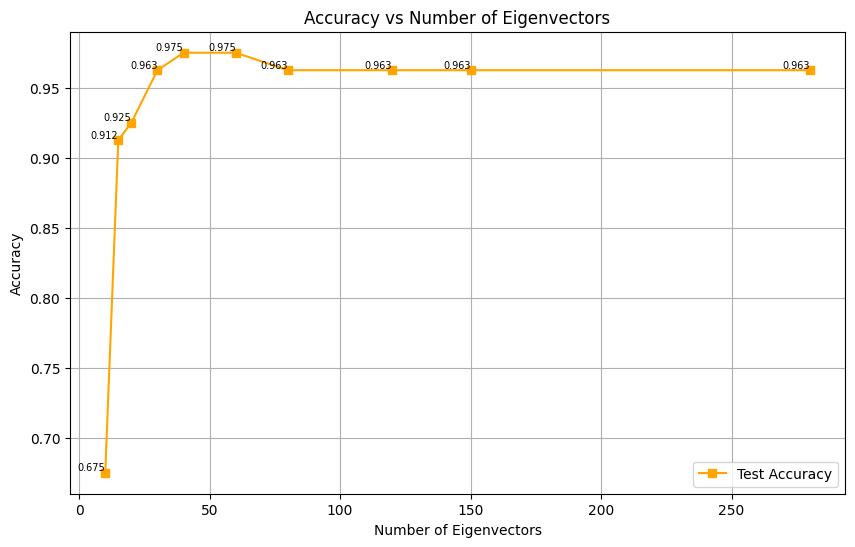

In [33]:
# PCA after subspace learning
#image reconstruction example
num_components = 10

q = Xtr.shape[0] # number of training samples 1x1
mu = np.mean(Xtr, axis=0) # mean of training data (4096,)

Xtr_centered = Xtr - mu # (320,4096)
X_test_centered = X_test - mu

# SVD for optimizing eigen decomposition
U, S, Vt = np.linalg.svd(Xtr_centered, full_matrices=False)

# Eigenvalues and Eigenvectors of St can be obtained from SVD results
eigenvalues = (S ** 2) / (q - 1) # (320,)
eigenvectors = Vt.T # (4096,320)

eigenvectors_subset = eigenvectors[:, :num_components]  # (4096,num_components)
Xtr_reduced = np.dot(Xtr_centered, eigenvectors_subset)  # (320,num_components)
Xtr_reconstructed = np.dot(Xtr_reduced, eigenvectors_subset.T) + mu

eigen_nums = [10, 15, 20, 30, 40, 60, 80,  120, 150, 280]
# reg_params = [0.01, 0.05,0.1, 0.5]
reg_params = [0.1]  
acc_train = [[0 for _ in eigen_nums] for _ in reg_params]
acc_test = []
i = 0
for reg in reg_params:
    j = 0
    for num in eigen_nums:
        eigenvectors_subset = eigenvectors[:, :num]  # (4096,num_components)
        Xtr_reduced = np.dot(Xtr_centered, eigenvectors_subset)  # (320,num_components)
        X_test_reduced = np.dot(X_test_centered, eigenvectors_subset)  # (80,num_components)
        Xtr_reconstructed = np.dot(Xtr_reduced, eigenvectors_subset.T) + mu

        classes = np.unique(ytr)
        class_means = np.array([Xtr_reduced[ytr == c].mean(axis=0) for c in classes])

        # Predict by nearest mean (min squared distance)

        clf = GaussianEnhancedProbSubspaceClassifier(m=m, reg=1e-4)
        clf.fit(Xtr_reduced, y_train)

        ypred_test = clf.predict(X_test_reduced)
        acc_test.append(accuracy_score(y_test, ypred_test))
        j += 1
    i += 1

# Plot accuracy vs number of eigenvectors
plt.figure(figsize=(10, 6))
plt.plot(eigen_nums, acc_test, marker='s', color='orange', label='Test Accuracy')
for x, y in zip(eigen_nums, acc_test):
    plt.text(x, y, f"{y:.3f}", ha='right', va='bottom', fontsize=7)
plt.title('Accuracy vs Number of Eigenvectors')
plt.xlabel('Number of Eigenvectors')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()
plt.show()
